In [14]:
import os
import random
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from PIL import Image
import warnings

# Abaikan peringatan EXIF dari PIL agar log tetap bersih
warnings.filterwarnings("ignore", "(Possibly )?corrupt EXIF data", UserWarning)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# Set Seed untuk konsistensi hasil
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [15]:
import shutil

# Path dataset asli (Read-only di Kaggle)
ORIGINAL_BASE_DIR = '/kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset' 

# Path dataset bersih (Bisa diedit di Kaggle)
WORKING_DIR = '/kaggle/working/dataset_clean'

TRAIN_DIR = os.path.join(WORKING_DIR, 'train')
VAL_DIR = os.path.join(WORKING_DIR, 'val')
TEST_DIR = os.path.join(WORKING_DIR, 'test')

# Parameter Gambar & Training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
MODEL_PATH = 'best_model.keras'

IMG_SHAPE = IMG_SIZE + (3,)
print("Image Shape yang digunakan:", IMG_SHAPE)
print("Target direktori kerja:", WORKING_DIR)

Image Shape yang digunakan: (224, 224, 3)
Target direktori kerja: /kaggle/working/dataset_clean


In [16]:
def prepare_clean_dataset(source_dir, target_dir):
    """Menyalin dataset ke working dir dan membersihkan file korup"""
    
    # 1. Salin dataset jika belum ada di target_dir
    if not os.path.exists(target_dir):
        print(f"Menyalin dataset dari {source_dir} ke {target_dir}...")
        shutil.copytree(source_dir, target_dir)
        print("Berhasil disalin!\n")
    else:
        print(f"Dataset sudah ada di {target_dir}, langsung tahap pembersihan...\n")

    # 2. Proses pembersihan STRICT
    print(f"Memulai pengecekan STRICT di: {target_dir}")
    num_deleted = 0
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    
    for root, dirs, files in os.walk(target_dir):
        for file in files:
            file_path = os.path.join(root, file)
            ext = os.path.splitext(file_path)[1].lower()
            
            # Hapus file dengan ekstensi aneh atau file tersembunyi
            if ext not in valid_extensions or file.startswith('.'):
                os.remove(file_path)
                num_deleted += 1
                continue
                
            # Hapus gambar yang tidak bisa dibaca penuh oleh PIL
            try:
                with Image.open(file_path) as img:
                    img.convert('RGB').load() 
            except Exception:
                print(f"Menghapus file rusak/tidak valid: {file_path}")
                os.remove(file_path)
                num_deleted += 1
                
    print(f"Pembersihan selesai! {num_deleted} file bermasalah berhasil dihapus.")

In [17]:
import os
import tensorflow as tf

# 1. Eksekusi copy dan pembersihan awal (PIL)
# Otomatis skip copy kalau folder sudah ada
prepare_clean_dataset(ORIGINAL_BASE_DIR, WORKING_DIR)

# 2. Definisi fungsi razia TensorFlow
def tf_strict_clean(directory):
    print(f"Memulai razia gambar dengan engine TensorFlow di: {directory}")
    num_deleted = 0
    
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            
            try:
                # Coba baca persis seperti cara model membaca gambar
                img_bytes = tf.io.read_file(file_path)
                _ = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
                
            except Exception:
                print(f"File korup ditemukan & dihapus: {file_path}")
                os.remove(file_path)
                num_deleted += 1
                
    print(f"Selesai! {num_deleted} file bermasalah telah dihapus dari {directory}.\n")

# 3. Eksekusi pembersihan super ketat (TensorFlow)
if os.path.exists(WORKING_DIR):
    tf_strict_clean(os.path.join(WORKING_DIR, 'train'))
    tf_strict_clean(os.path.join(WORKING_DIR, 'val'))
else:
    print("Folder dataset_clean belum ada. Proses copy sepertinya gagal!")

Dataset sudah ada di /kaggle/working/dataset_clean, langsung tahap pembersihan...

Memulai pengecekan STRICT di: /kaggle/working/dataset_clean


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Pembersihan selesai! 0 file bermasalah berhasil dihapus.
Memulai razia gambar dengan engine TensorFlow di: /kaggle/working/dataset_clean/train
Selesai! 0 file bermasalah telah dihapus dari /kaggle/working/dataset_clean/train.

Memulai razia gambar dengan engine TensorFlow di: /kaggle/working/dataset_clean/val
Selesai! 0 file bermasalah telah dihapus dari /kaggle/working/dataset_clean/val.



In [18]:
print("--- Memuat Dataset Training ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n--- Memuat Dataset Validasi ---")
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f'\nBerhasil memuat {NUM_CLASSES} kelas serangga: {class_names}')

--- Memuat Dataset Training ---
Found 90014 files belonging to 118 classes.

--- Memuat Dataset Validasi ---
Found 11205 files belonging to 118 classes.

Berhasil memuat 118 kelas serangga: ['adristyrannus', 'aleurocanthus spiniferus', 'alfalfa plant bug', 'alfalfa seed chalcid', 'alfalfa weevil', 'ampelophaga', 'ant', 'aphids', 'apolygus lucorum', 'armyworm', 'asiatic rice borer', 'bactrocera tsuneonis', 'bee', 'beet fly', 'beetle', 'black cutworm', 'blister beetle', 'bollworm', 'brevipoalpus lewisi McGregor', 'brown plant hopper', 'butterfly', 'catterpillar', 'cerodonta denticornis', 'ceroplastes rubens', 'chayon', 'chlumetia transversa', 'chrysomphalus aonidum', 'cicadella viridis', 'cicadellidae', 'corn borer', 'dacus dorsalis(Hendel)', 'dasineura sp', 'deporaus marginatus Pascoe', 'dragonfly', 'earthworm', 'earwig', 'erythroneura apicalis', 'fall armyworm', 'flax budworm', 'flea beetle', 'fly', 'grain spreader thrips', 'grasshopper', 'grub', 'icerya purchasi Maskell', 'kolorado', 

In [19]:
# Mempercepat proses baca gambar dari disk menggunakan memori cache
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
print("Optimasi prefetch dan cache dataset selesai dikonfigurasi.")

Optimasi prefetch dan cache dataset selesai dikonfigurasi.


In [20]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

print("Layer augmentasi data siap digunakan.")

Layer augmentasi data siap digunakan.


In [21]:
def create_efficientnet_model(input_shape, num_classes):
    # Load pretrained model tanpa top layer
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze awal untuk feature extraction
    
    # Membangun arsitektur lengkap
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name="Insect_Classifier_EfficientNet")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [22]:
# Cek apakah sudah ada file simpanan training sebelumnya
if os.path.exists(MODEL_PATH):
    print(f"Menemukan file model lama di '{MODEL_PATH}'. Melanjutkan dari epoch terakhir...")
    model = tf.keras.models.load_model(MODEL_PATH)
else:
    print("Tidak ditemukan model lama. Membuat model baru dari awal...")
    model = create_efficientnet_model(input_shape=IMG_SHAPE, num_classes=NUM_CLASSES)

model.summary()

Tidak ditemukan model lama. Membuat model baru dari awal...


Model: "Insect_Classifier_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 118)            │       151,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,200,729 (16.02 MB)

 Trainable params: 151,158 (590.46 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
callbacks = [
    # 1. Menyimpan model terbaik berdasarkan val_accuracy terbesar
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, 
        save_best_only=True, 
        monitor='val_accuracy', 
        mode='max',
        verbose=1
    ),
    
    # 2. Menurunkan lr otomatis saat loss mulai mendatar agar konvergen lebih halus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        min_lr=1e-6,
        verbose=1
    ),
    
    # 3. Berhenti otomatis jika val_loss tidak turun selama 6 epoch berturut-turut
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=6, 
        restore_best_weights=True,  # Mengembalikan bobot terbaik, bukan dari epoch terakhir yang jelek
        verbose=1
    )
]

print("Callbacks untuk otomatisasi training telah aktif.")

Callbacks untuk otomatisasi training telah aktif.


In [27]:
# Set jumlah maksimum epoch yang besar. EarlyStopping yang akan mengontrol kapan harus berhenti.
MAX_EPOCHS = 10 

print("Memulai proses training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks
)

Memulai proses training...
Epoch 1/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6992 - loss: 1.0826
Epoch 1: val_accuracy did not improve from 0.71593
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 229s 81ms/step - accuracy: 0.6995 - loss: 1.0770 - val_accuracy: 0.7150 - val_loss: 1.1021 - learning_rate: 1.2500e-04
Epoch 2/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7005 - loss: 1.0826
Epoch 2: val_accuracy did not improve from 0.71593
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 235s 84ms/step - accuracy: 0.6999 - loss: 1.0798 - val_accuracy: 0.7150 - val_loss: 1.1006 - learning_rate: 1.2500e-04
Epoch 3/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7005 - loss: 1.0804
Epoch 3: val_accuracy did not improve from 0.71593
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 236s 84ms/step - accuracy: 0.6991 - loss: 1.0800 - val_accuracy: 0.7137 - val_loss: 1.0997 - learning_rate: 1.2500e-04
Epoch 4/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6985 - loss: 1.0817
Epoch 4: val_a

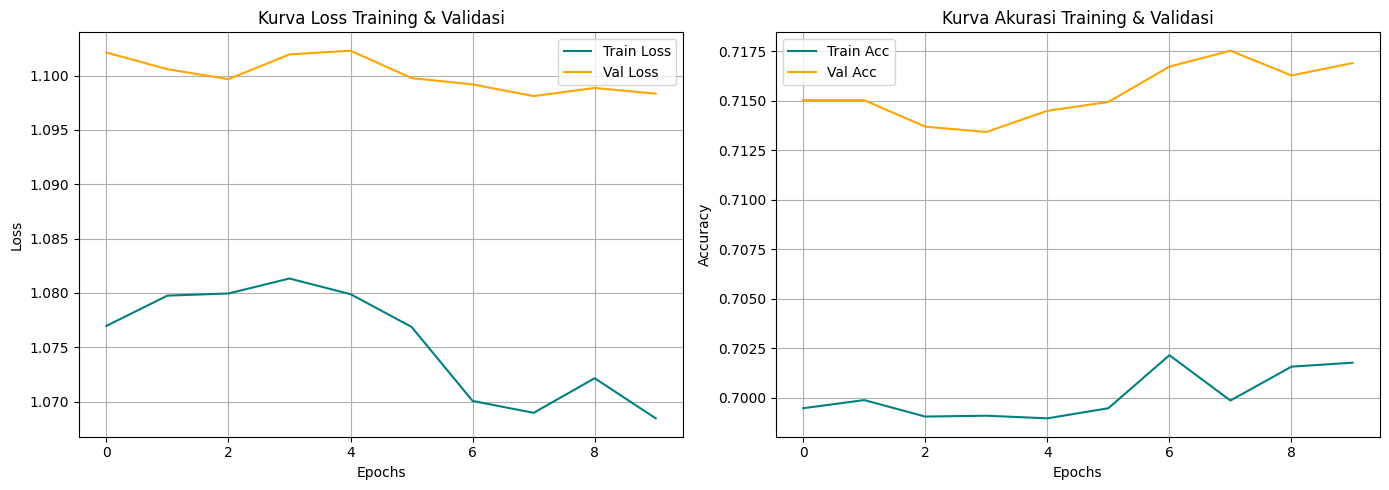

In [28]:
def plot_training_results(training_history):
    if not hasattr(training_history, 'history') or not training_history.history:
        print("History training kosong atau training di-resume tanpa record baru.")
        return
        
    metrics_df = pd.DataFrame(training_history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    axes[0].plot(metrics_df['loss'], label='Train Loss', color='teal')
    axes[0].plot(metrics_df['val_loss'], label='Val Loss', color='orange')
    axes[0].set_title('Kurva Loss Training & Validasi')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot Accuracy
    axes[1].plot(metrics_df['accuracy'], label='Train Acc', color='teal')
    axes[1].plot(metrics_df['val_accuracy'], label='Val Acc', color='orange')
    axes[1].set_title('Kurva Akurasi Training & Validasi')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_results(history)

Mengkalkulasi prediksi data validasi (sinkronisasi urutan)...


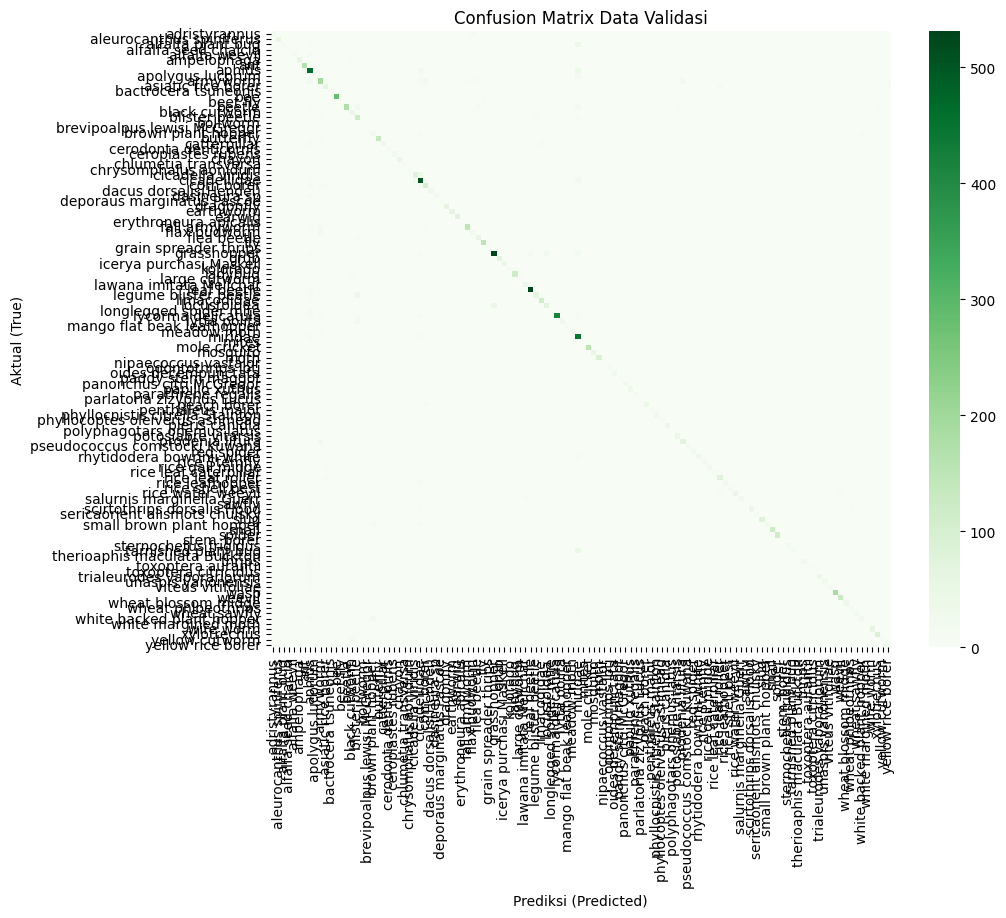


--- Classification Report ---
                                 precision    recall  f1-score   support

                  adristyrannus       0.57      0.52      0.54        31
       aleurocanthus spiniferus       0.77      0.84      0.81        69
              alfalfa plant bug       0.50      0.15      0.24        65
           alfalfa seed chalcid       0.50      0.22      0.31        18
                 alfalfa weevil       0.57      0.40      0.47        52
                    ampelophaga       0.68      0.78      0.72        76
                            ant       0.90      0.87      0.88       191
                         aphids       0.59      0.75      0.66       620
               apolygus lucorum       0.54      0.18      0.27        38
                       armyworm       0.47      0.54      0.50       353
             asiatic rice borer       0.45      0.56      0.50       105
           bactrocera tsuneonis       0.70      0.44      0.54        16
                   

In [30]:
print("Mengkalkulasi prediksi data validasi (sinkronisasi urutan)...")
y_true = []
y_pred = []

# Melakukan prediksi batch demi batch dalam satu perulangan yang sama
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Data Validasi')
plt.ylabel('Aktual (True)')
plt.xlabel('Prediksi (Predicted)')
plt.show()

# Print Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))
print('Macro F1 Score:', f1_score(y_true, y_pred, average='macro'))

In [33]:
print("Mulai fine-tuning...")

# Ambil base model (EfficientNetB0)
base_model = model.get_layer('efficientnetb0')

# Unfreeze semua layer dulu
base_model.trainable = True

# Freeze 100 layer pertama biar fitur deteksi dasar (garis, tepi) gak rusak
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layer: {len(base_model.layers)}")
print(f"Layer yang di-train ulang: {len(base_model.layers) - fine_tune_at}")

# Compile ulang, set learning rate super kecil (1e-5) biar bobot lama gak hancur
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Setup callbacks buat fine-tuning
callbacks_finetune = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, 
        save_best_only=True, 
        monitor='val_accuracy', 
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

# Jalankan training
FINETUNE_EPOCHS = 5
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks_finetune
)

Mulai fine-tuning...
Total layer: 238
Layer yang di-train ulang: 138
Epoch 1/5


E0000 00:00:1780511599.834082     356 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Insect_Classifier_EfficientNet_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7829 - loss: 0.7445
Epoch 1: val_accuracy improved from None to 0.77055, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 499s 168ms/step - accuracy: 0.7853 - loss: 0.7417 - val_accuracy: 0.7705 - val_loss: 0.8802
Epoch 2/5
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7898 - loss: 0.7260
Epoch 2: val_accuracy improved from 0.77055 to 0.77269, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 474s 169ms/step - accuracy: 0.7897 - loss: 0.7231 - val_accuracy: 0.7727 - val_loss: 0.8749
Epoch 3/5
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7885 - loss: 0.7217
Epoch 3: val_accuracy did not improve from 0.77269
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 472s 168ms/step - accuracy: 0.7910 - loss: 0.7131 - val_accuracy: 0.7722 - val_loss: 0.8712
Epoch 4/5
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 

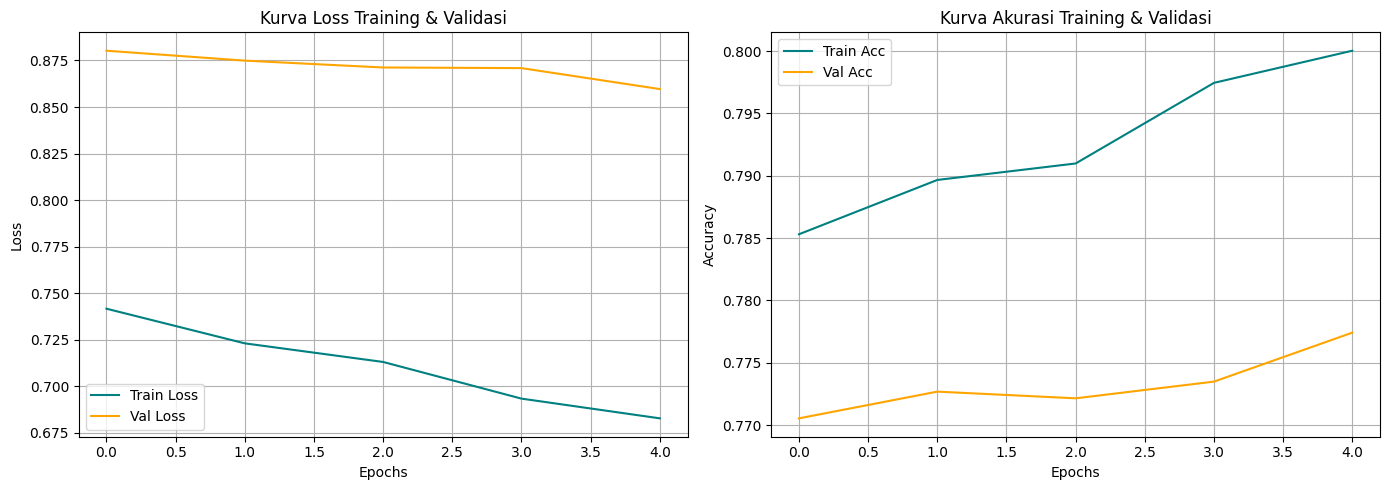

Model saved to: insect_classifier_model.h5


In [34]:
# Cek grafik hasil fine-tuning
plot_training_results(history_finetune) 

# Save model ke .h5 buat diload di FastAPI (ml_service.py) nanti
EXPORT_PATH = 'insect_classifier_model.h5'
model.save(EXPORT_PATH)

print(f"Model saved to: {EXPORT_PATH}")
# File h5 siap didownload dari /kaggle/working/